In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm
plt.rcParams['font.sans-serif'] = 'Helvetica'

In [20]:
adsweepres = 20
kpsweepres = 20
bsweepres = 2
tsweepres= 3
allbeta = [0.1,0.25]
allT = [1,2]
tsweepres= len(allT)
stabilityplot = np.zeros((adsweepres,adsweepres,bsweepres,tsweepres))

tt=-1
for T in allT:
    tt+=1
    kk = -1
    for b in allbeta:
        kk += 1
        ii = -1
        for a in np.linspace(0.0,1.0,adsweepres):
            ii += 1
            jj = -1
            for d in np.linspace(0,1,adsweepres):
                jj +=1
                minmaxeig = 1e6
                A = [[a,b],
                     [b,a]]
                A = expm(np.array(A)*T)
                for k in  A[0,0]*np.linspace(0,1,kpsweepres):
                    for p in A[0,-1]*np.linspace(0,1,kpsweepres):
                        K = [[-k+p*d,-p+k*d],
                             [-p+k*d,-k+p*d]]
                        K = np.array(K)
                        maxeig = np.max(np.abs(np.linalg.eigvals(A+K)))
                        if maxeig < minmaxeig:
                            minmaxeig = maxeig
                stabilityplot[ii,jj,kk,tt] = minmaxeig 


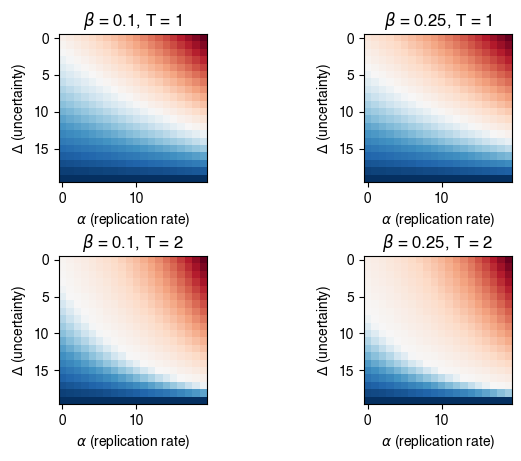

In [21]:
plt.figure()

pltInd = 0
for tt in range(len(allT)):
    for bb in range(len(allbeta)): 
        pltInd += 1
        plt.subplot(len(allT),len(allbeta),pltInd)
        # rescale image so that 0 to 1 is blue and 1 to 2 is red
        showthisarray = np.flipud(np.transpose(stabilityplot[:,:,bb,tt]))*1.0
        if np.any(showthisarray <= 1.0):
            showthisarray[showthisarray <= 1.0] = showthisarray[showthisarray <= 1.0]/np.ptp(showthisarray[showthisarray <= 1.0])*.5
        if np.any(showthisarray > 1.0):
            showthisarray[showthisarray > 1.0] = (showthisarray[showthisarray > 1.0]-1.0)/np.ptp(showthisarray[showthisarray > 1.0])*.5+.5
        plt.imshow(showthisarray,cmap='RdBu_r')
        plt.title(r'$\beta$ = ' + str(allbeta[bb]) + ', T = ' + str(allT[tt]))
        plt.ylabel(r'$\Delta$ (uncertainty)')
        plt.xlabel(r'$\alpha$ (replication rate)')
        plt.clim((0,1.0))
        # plt.colorbar()
        plt.subplots_adjust(hspace=0.5, wspace=0.6)